In [13]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Spectrum fitting
from PyMca5.PyMcaPhysics.xrf import ClassMcaTheory
from PyMca5.PyMcaPhysics.xrf import FastXRFLinearFit
from PyMca5.PyMcaPhysics.xrf import McaAdvancedFitBatch
# File I/O
from PyMca5.PyMcaIO import EdfFile
from PyMca5.PyMcaIO import specfilewrapper as specfile
# Configuration
from PyMca5.PyMcaIO import ConfigDict
# Stack/imaging data
from PyMca5.PyMcaIO import HDF5Stack1D

import os
os.chdir ("/home/kdetest/Documents/VICCO/Geochemistry/Cuttings_XRF-XRD/")

In [28]:
# # --- Calibration from the energy axis ---
# # Energy = zero + gain * channel
# gain = energy_keV[1] - energy_keV[0]   # 0.015 keV/channel
# zero = energy_keV[0]                    # 0.0 keV
# n_channels = len(energy_keV)
# channels = np.arange(n_channels)

# print(f"Calibration:  zero={zero:.4f} keV,  gain={gain:.4f} keV/ch")
cfg = ConfigDict.ConfigDict()

# --- Detector ---
cfg["detector"] = {
    "zero":         0.0,
    "gain":         0.015,
    "noise":        0.1,
    "fano":         0.114,
    "sum":          1e-8,
    "detele":       "Si",      # ← required — detector crystal element
    "detene":       1.7420,    # Si escape energy (keV) — optional, has default
    "ethreshold":   0.020,     # energy threshold — optional, has default
    "ithreshold":   1.0e-07,   # intensity threshold — optional, has default
    "nthreshold":   4,         # n threshold — optional, has default
    # delta/fixed flags
    "deltazero":    0.1,
    "deltagain":    0.001,
    "deltanoise":   0.05,
    "deltafano":    0.114,
    "deltasum":     1e-8,
    "fixedzero":    0,
    "fixedgain":    0,
    "fixednoise":   0,
    "fixedfano":    0,
    "fixedsum":     0,
}

# --- Beam energy (Niton XL3T has 4 beam conditions; ~50 keV main beam) ---
cfg["fit"] = {
    # Beam Info
    "energy":       [50.0, 0.0, 0.0, 0.0],
    "energyweight": [1.0,  0.0, 0.0, 0.0],
    "energyflag":   [1,    0,   0,   0],
    "energyscatter":[1,    0,   0,   0],
    # Fit Range
    # "xmin":          int(0.4 / gain),    # keV — low-energy cut - not used with hardcoded channel values below
    # "xmax":          int(53.75 / gain),   # keV — high-energy cut
    "xmin": 27,
    "xmax": 3583,
    "use_limit":     0,
    # Background ranges
    "continuum":     1,      # 0=none, 1=constant, 2=linear, 3=strip, 4=SNIP
    "stripiterations": 20000,
    "snipwidth":     30,
    "stripflag": 0,     # 0 = no strip background (use continuum instead)
    "stripanchorsflag": 0,        # safe (has __configure default) but be explicit
    "stripanchorslist": [0,0,0,0],
    # Peak Shape
    "fitfunction":   0,      # 0 = hypermet
    "hypermetflag": 1,      # 1 = use hypermet peak shape (recommended for XRF)
    "escapeflag": 1,        # 1 = calculate Si escape peaks
    "sumflag": 0,       # 0 = no pile-up correction
    "scatterflag":      0,        # safe (has __configure default) but be explicit
    # Polynomial Background Orders
    "linpolorder":      5,        # ← missing — required hard lookup
    "exppolorder":      6,        # ← missing — required hard lookup
    "linearfitflag":    0,        # ← missing — required hard lookup
    # Convergence 
    "maxiter": 50,
    "deltachi": 1e-05,
    "deltaonepeak":     0.010,    # safe (has __configure default) but be explicit
    "fitweight":        1,        # safe (has __configure default) but be explicit

}

# --- Elements to fit ---
cfg["peaks"] = {
    "Si": ["K"],
    "S":  ["K"],
    "Ca": ["K"],
    "Fe": ["K"],
    "Ti": ["K"],
    "Mn": ["K"],
    "Zn": ["K"],
    "Sr": ["K"],
    "Ba": ["L"],
}

cfg["concentrations"] = {
    "usematrix":        1,       # 0 = use fundamental parameters
    "useattenuators":   1,
    "flux":             1e10,    # photons/s (Niton typical)
    "time":             1.0,     # seconds
    "area":             30.0,    # mm² detector active area
    "distance":         10.0,    # mm sample-to-detector
    "reference":        "Auto",
}

# Matrix = the sample (use generic rock/soil composition)
cfg["attenuators"] = {
    # "Matrix": [1, "SiO2", 2.65, 0.0, 90.0, 90.0],  
    "Matrix": [1, "Si", 2.65, 0.0, 90.0, 90.0],  
    # [flag, material, density, thickness, alphain, alphaout]
}

# Save it
cfg.write("my_config.cfg")
print("Config saved.")

# This next part is crucial to stop fix behaviour with %
# with open("my_config.cfg", "r") as f:
#     txt = f.read()
# txt = txt.replace("wt%%", "wt%")          # replace the escaped version
# with open("my_config.cfg", "w") as f:
#     f.write(txt)

Config saved.


In [24]:
# df = pd.read_csv("25_7-5_CUTTINGS_XRF_RAW_1.CSV",
#                  skiprows=4,     # skip the 4 metadata rows
#                  index_col=0,
#                  encoding="latin-1")    # sample ID (e.g. "1350m (Main Range)") as index

# # The column names are already energy values as strings; convert to float
# energy_keV = df.columns.astype(float).values   # shape: (n_channels,)
# print(f"Energy range: {energy_keV[0]:.3f} – {energy_keV[-1]:.3f} keV")
# print(f"Spectra loaded: {df.shape[0]}")
# print(df.index.tolist())


# --- Load CSV ---
df = pd.read_csv("25_7-5_CUTTINGS_XRF_RAW_1.CSV", skiprows=4, index_col=0, encoding="latin-1")
df.index = df.index.str.replace("\xa0", " ", regex=False).str.strip()

# --- Derive axis variables once — used everywhere below ---
energy_keV = df.columns.astype(float).values
gain       = energy_keV[1] - energy_keV[0]   # 0.015 keV/channel
zero       = energy_keV[0]                    # 0.0 keV
channels   = np.arange(len(energy_keV))       # [0, 1, 2, ..., 3999]

In [25]:
def parse_sample_id(sid):
    """Extract depth (m) and range type from a sample ID string."""
    m = re.match(r"(\d+)m \((.+)\)", sid.strip())
    if m:
        return int(m.group(1)), m.group(2)
    return None, sid

depths  = sorted(set(parse_sample_id(s)[0] for s in df.index))
ranges_ = sorted(set(parse_sample_id(s)[1] for s in df.index))
print("Depths (m):", depths)
print("Ranges:    ", ranges_)

def get_spectrum(depth_m, range_type="Main Range"):
    """Return counts array for a given depth and range type."""
    label = f"{depth_m}m ({range_type})"
    return df.loc[label].values.astype(float)

Depths (m): [1350, 1360, 1370, 1380, 1390, 1400, 1410, 1420, 1430, 1440, 1460, 1470, 1480, 1490, 1500, 1510, 1520, 1530, 1540, 1550, 1560, 1570, 1580, 1590, 1600, 1620, 1630, 1640, 1650, 1660, 1670, 1680, 1690, 1700, 1710, 1720, 1730, 1740, 1750, 1760, 1770, 1780, 1790, 1800, 1810, 1820, 1830, 1840, 1850, 1855, 1860, 1865, 1870, 1872, 1875, 1877, 1880, 1882, 1885, 1890, 1892, 1895, 1897, 1900, 1902, 1905, 1907, 1910, 1912, 1915, 1917, 1920, 1922, 1927, 1930, 1932, 1935, 1937, 1940, 1942, 1945, 1947, 1950, 1952, 1955, 1957, 1960, 1962, 1965, 1967, 1970, 1972, 1975, 1977, 1980, 1982, 1985, 1987, 1990, 1992, 1995, 1997, 2000, 2002, 2005, 2007, 2010, 2012, 2015, 2017, 2020, 2025, 2030, 2032, 2035, 2052, 2060, 2062, 2065, 2067, 2070, 2072, 2075, 2077, 2080, 2082, 2085, 2087, 2090, 2092, 2097, 2100, 2107, 2112, 2117, 2120, 2122, 2130, 2135, 2150, 2152, 2155, 2157, 2162, 2165, 2170, 2175, 2180, 2185, 2195, 2200, 2202, 2210, 2215, 2220, 2222, 2227, 2230, 2235, 2240, 2247, 2250, 2252, 2257, 226

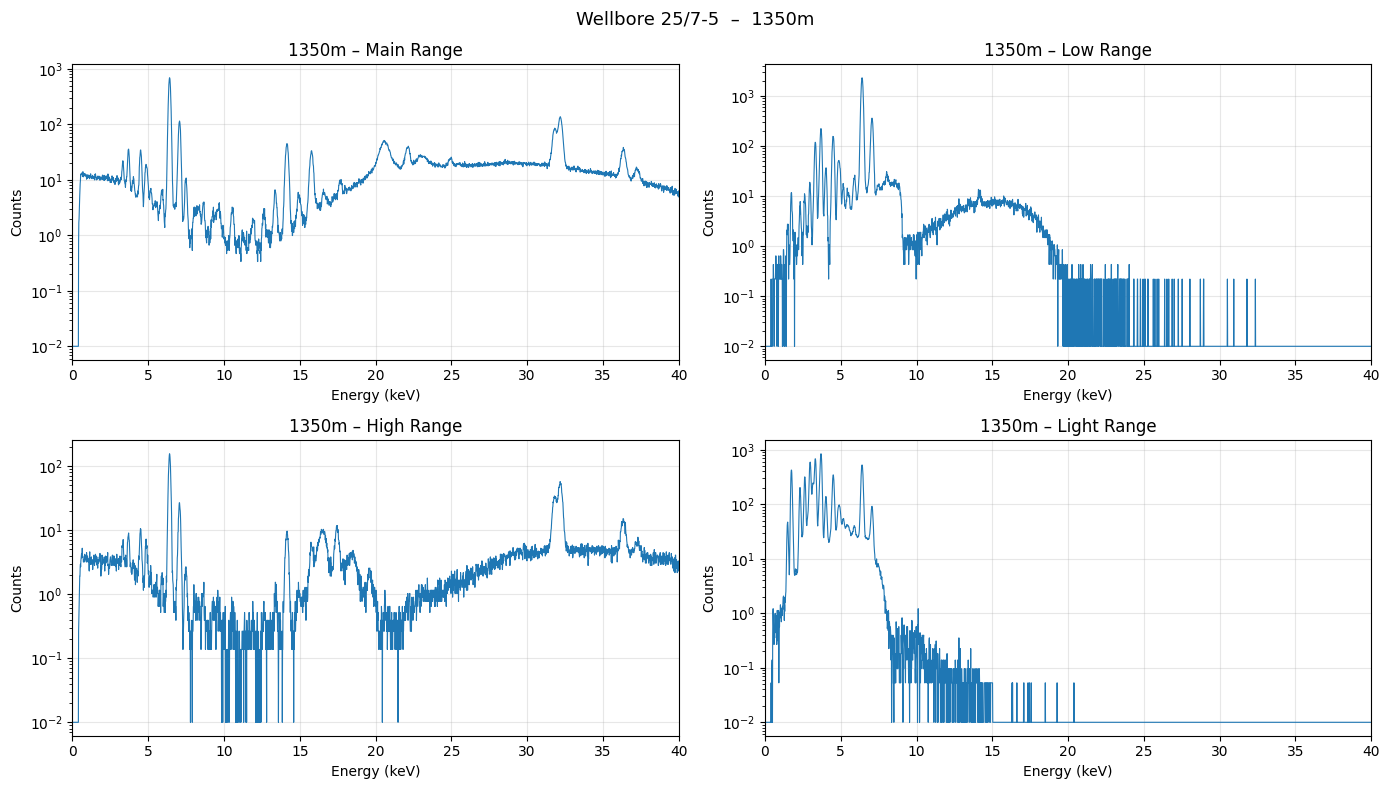

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
range_types = ["Main Range", "Low Range", "High Range", "Light Range"]
depth = 1350

for ax, rtype in zip(axes.flat, range_types):
    counts = get_spectrum(depth, rtype)
    ax.semilogy(energy_keV, counts + 0.01, lw=0.8)   # +0.01 avoids log(0)
    ax.set_title(f"{depth}m – {rtype}")
    ax.set_xlabel("Energy (keV)")
    ax.set_ylabel("Counts")
    ax.set_xlim(0, 40)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Wellbore 25/7-5  –  {depth}m", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
fitter = FastXRFLinearFit.FastXRFLinearFit()
fitter.setFitConfigurationFile("my_config.cfg")

# Collect all Main Range spectra in depth order
main_range_rows = [s for s in df.index if "Main Range" in s]
stack = df.loc[main_range_rows].values.astype(float)   # shape: (n_depths, n_channels)
sum_spectrum = stack.sum(axis=0)

# result = fitter.fitMultipleSpectra(
#     x    = channels,
#     y    = stack,
#     ysum = sum_spectrum
# )

# labels        = result.labels("parameters")   # ← method call, not dict key
# element_areas = result["parameters"]          # shape: (n_elements, n_depths)

result = fitter.fitMultipleSpectra(
    x              = channels,
    y              = stack,
    ysum           = sum_spectrum,
    # xmin           = int(0.4   / gain),
    # xmax           = int(53.75 / gain),
    concentrations = 1           # ← enables weight percent output
)

conc = FastXRFLinearFit.fitDeriveMassFractions()

concresult = conc.fitMultipleSpectra(
    x              = channels,
    y              = stack,
    ysum           = sum_spectrum,
    # xmin           = int(0.4   / gain),
    # xmax           = int(53.75 / gain),
    concentrations = 1           # ← enables weight percent output
)
# Results are now in a separate concentrations buffer
labels_conc  = result.labels("concentrations")
weight_pct   = result["concentrations"]   # shape: (n_elements, n_depths)

# print("Elements fitted:", labels)

# -------------------------------------------------------------
# 8️⃣  Extract the two result tables
# -------------------------------------------------------------
# 8a – Net areas  (for reference or sanity checks)
area_labels   = result.labels("parameters")          # e.g. ['Fe K', 'Ca K', …]
area_matrix   = result["parameters"]                 # (n_el, n_depth)

# 8b – **Concentrations** (already FP‑corrected)
conc_labels   = result.labels("concentrations")      # e.g. ['Fe K (wt%)', …]
conc_matrix   = result["concentrations"]

print("Result containers available :", list(result.keys()))

AttributeError: module 'PyMca5.PyMcaPhysics.xrf.FastXRFLinearFit' has no attribute '_fitDeriveMassFractions'

In [ ]:
# # --- Diagnostic: check what the fitter actually has ---
# cfg_check = fitter._mcaTheory.getConfiguration()

# print("=== PEAKS IN CONFIG ===")
# print(cfg_check.get("peaks", {}))

# print("\n=== FIT RANGE ===")
# print("use_limit:", cfg_check["fit"]["use_limit"])
# print("xmin     :", cfg_check["fit"]["xmin"])
# print("xmax     :", cfg_check["fit"]["xmax"])

# print("\n=== DETECTOR ===")
# print("zero     :", cfg_check["detector"]["zero"])
# print("gain     :", cfg_check["detector"]["gain"])
# print("detele   :", cfg_check["detector"]["detele"])

# print("\n=== BEAM ENERGY ===")
# print("energy   :", cfg_check["fit"]["energy"])

In [ ]:
# --- Select which range to fit ---
RANGE = "Main Range"   # change to "Low Range" etc. if needed

main_rows   = [s for s in df.index if RANGE in s]
stack       = df.loc[main_rows].values.astype(float)   # (n_depths, n_channels)
sum_spectrum = stack.sum(axis=0)

# --- Fit ---
fitter = FastXRFLinearFit.FastXRFLinearFit()
fitter.setFitConfigurationFile("my_config.cfg")

result        = fitter.fitMultipleSpectra(x=channels, y=stack, ysum=sum_spectrum, concentrations=True)
labels        = result.labels("parameters")          # e.g. ['Fe K', 'Ca K', ...]
element_areas = result["parameters"]                 # shape: (n_elements, n_depths)

# --- Parse depth labels ---
depths = [int(s.replace(f"m ({RANGE})", "").strip()) for s in main_rows]

# --- Build results dataframe (areas) ---
areas_df = pd.DataFrame(
    element_areas.T,          # transpose → (n_depths, n_elements)
    index=depths,
    columns=labels
)
areas_df.index.name = "Depth_m"

# --- Relative proportions (each depth row sums to 1) ---
proportions_df = areas_df.div(areas_df.sum(axis=1), axis=0)

# --- Save ---
areas_df.to_csv("element_areas.csv")
proportions_df.to_csv("element_proportions.csv")

print(proportions_df.round(4))

In [ ]:
# --- Plot element depth profiles ---
depth_values = [parse_sample_id(s)[0] for s in main_range_rows]

fig, axes = plt.subplots(1, min(6, len(labels)), figsize=(16, 5))
for ax, elem, idx in zip(axes, labels[:6], range(6)):
    ax.plot(element_areas[idx], depth_values, marker="o", ms=4)
    ax.invert_yaxis()
    ax.set_title(elem)
    ax.set_xlabel("Net area")
    ax.set_ylabel("Depth (m)")
    ax.grid(True, alpha=0.3)

plt.suptitle("Wellbore 25/7-5 – Elemental depth profiles", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# results_df = pd.DataFrame(
#     element_areas.T,
#     index=depth_values,
#     columns=labels
# )
# results_df.index.name = "Depth_m"
# results_df.to_csv("wellbore_25_7_5_elements.csv")
# print(results_df.head())